[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MessaAlberto/dataMining_aviationNetworks/blob/main/main.ipynb)

# **Decoding Global Aviation Networks**

### **Setup**: Import Libraries and Configure Environment

In [1]:
%pip install pyspark datasketch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 3.9 MB/s eta 0:00:00


In [ ]:
import difflib
import glob
import os
import random
import time
import warnings
import zipfile
import gdown

from google.colab import drive

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.cluster.hierarchy as shc
import scipy.stats as scipy_stats
from datasketch import MinHash, MinHashLSH

from sklearn.cluster import KMeans as SklearnKMeans
from sklearn.cluster import DBSCAN as SklearnDBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler as SklearnScaler

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

# Warnings and plotting config
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
plt.rcParams.update({"figure.max_open_warning": 0})

drive.mount('/content/drive')

BASE_PATH = "/content"
DATA_DIR = os.path.join(BASE_PATH, "data")
ZIP_PATH = os.path.join(BASE_PATH, "data.zip")

FILE_ID = "1TLUp_xnYthDtRCGPSwNVu-1t39tnvgtp"   # Google Drive file ID for the dataset zip

OPENFLIGHTS_PATH = os.path.join(DATA_DIR, "openflights")
BTS_PATH = os.path.join(DATA_DIR, "bts_usa")
ANAC_PATH = os.path.join(DATA_DIR, "anac_br")
CAA_PATH = os.path.join(DATA_DIR, "caa_uk")

if os.path.exists(DATA_DIR) and os.listdir(DATA_DIR):
    print("Dataset already present. Skipping download.")
else:
    # Download zip only if not already present
    if not os.path.exists(ZIP_PATH):
        print("Downloading dataset...")
        gdown.download(
            f"https://drive.google.com/uc?id={FILE_ID}",
            ZIP_PATH,
            quiet=False
        )

    # Extract zip
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(BASE_PATH)

    print("Extraction completed.")

print(f"Dataset directory: {DATA_DIR}")
os.chdir(DATA_DIR)


Mounted at /content/drive


Downloading...
From (original): https://drive.google.com/uc?id=1TLUp_xnYthDtRCGPSwNVu-1t39tnvgtp
From (redirected): https://drive.google.com/uc?id=1TLUp_xnYthDtRCGPSwNVu-1t39tnvgtp&confirm=t&uuid=6ebc37dc-5fd7-4d9b-8b8b-da84210c9142
To: /content/data.zip
100%|██████████| 416M/416M [00:04<00:00, 89.8MB/s]


Extracting dataset...
Extraction completed.
Dataset directory: /content/data


In [ ]:
try:
    spark
except NameError:
    spark = SparkSession.builder \
        .appName("AirportNetworkAnalysis") \
        .config("spark.executor.memory", "4g") \
        .getOrCreate()

print("Spark Session Active. UI link usually at port 4040.")

Spark Session Active. UI link usually at port 4040.


---
### **Phase 1**: Data Ingestion and Preprocessing

Loading **OpenFlights** datasets: airports, routes.

In [4]:
print("Reading raw data with PySpark...")

df_airports_spark = spark.read.option("header", "true") \
    .option("nullValue", "\\N") \
    .option("inferSchema", "true") \
    .csv(os.path.join(OPENFLIGHTS_PATH, "airports.csv"))

df_routes_spark = spark.read.option("header", "true") \
    .option("nullValue", "\\N") \
    .option("inferSchema", "true") \
    .csv(os.path.join(OPENFLIGHTS_PATH, "routes.csv"))

# Filter on IATA (3-letter codes)
df_nodes = df_airports_spark.filter(F.col("IATA").rlike("^[A-Z]{3}$")) \
    .select("IATA", "Name", "City", "Country", "Latitude", "Longitude") \
    .withColumn("Latitude", F.col("Latitude").cast(DoubleType())) \
    .withColumn("Longitude", F.col("Longitude").cast(DoubleType()))

# Filter on IATA and direct flights (Stops == 0)
df_edges = df_routes_spark.filter(F.col("SourceAirport").rlike("^[A-Z]{3}$")) \
    .filter(F.col("DestAirport").rlike("^[A-Z]{3}$")) \
    .filter(F.col("Stops") == 0) \
    .select(F.col("SourceAirport").alias("src"), F.col("DestAirport").alias("dst"))

n_nodes_init = df_nodes.count()
n_edges_init = df_edges.count()
print(f"Raw Input: {n_nodes_init} airports, {n_edges_init} routes.")


Reading raw data with PySpark...
Raw Input: 6071 airports, 67652 routes.


Cleaning data:
- Referential Integrity: Remove routes to non-existent airports.
- Self-loops: Remove routes where source and destination are the same.
- Duplicate Routes: Remove duplicate entries (same source-destination pair).
- Isolated Nodes: Remove airports without any connecting flights.

In [5]:
print("\nCleaning Graph Data...")

# A. Referential Integrity (Removes routes to non-existent airports)
df_edges = df_edges.join(df_nodes, df_edges.src == df_nodes.IATA, "left_semi")
df_edges = df_edges.join(df_nodes, df_edges.dst == df_nodes.IATA, "left_semi")

n_edges_step_a = df_edges.count()
diff_a = n_edges_init - n_edges_step_a
if diff_a > 0:
    print(f"    - Referential Integrity: Dropping {diff_a} phantom routes (unknown airports).")

# B. Self-Loops
df_edges = df_edges.filter(F.col("src") != F.col("dst"))

n_edges_step_b = df_edges.count()
diff_b = n_edges_step_a - n_edges_step_b
if diff_b > 0:
    print(f"    - Self-Loops: Dropping {diff_b} circular routes (src == dst).")

# C. Duplicates
df_edges = df_edges.dropDuplicates(["src", "dst"])

n_edges_step_c = df_edges.count()
diff_c = n_edges_step_b - n_edges_step_c
if diff_c > 0:
    print(f"    - Deduplication: Merged {diff_c} duplicate routes.")

# D. Isolated Nodes
active_src = df_edges.select(F.col("src").alias("IATA"))
active_dst = df_edges.select(F.col("dst").alias("IATA"))
active_nodes = active_src.union(active_dst).distinct()

# Keep only active nodes in the final node set (Semi Join)
df_nodes_final = df_nodes.join(active_nodes, "IATA", "left_semi")

n_nodes_final = df_nodes_final.count()
diff_d = n_nodes_init - n_nodes_final
if diff_d > 0:
    print(f"    - Connectivity: Dropping {diff_d} isolated airports (noise).")

print(f"Graph Cleaned: {n_nodes_final} nodes, {n_edges_step_c} edges.")
print("\nMaterializing cleaned data to Pandas for Graph construction...")
pdf_nodes = df_nodes_final.toPandas()
pdf_edges = df_edges.toPandas()

print("\nBuilding Graph G...")
G = nx.from_pandas_edgelist(pdf_edges, "src", "dst", create_using=nx.DiGraph())
G.add_nodes_from(pdf_nodes["IATA"])

node_attr = pdf_nodes.set_index("IATA")[["Name", "City", "Country", "Latitude", "Longitude"]].to_dict('index')
nx.set_node_attributes(G, node_attr)

df_master_nodes = pdf_nodes
print(f"    -> Final Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges.\n")


Cleaning Graph Data...
    - Referential Integrity: Dropping 729 phantom routes (unknown airports).
    - Self-Loops: Dropping 1 circular routes (src == dst).
    - Deduplication: Merged 29881 duplicate routes.
    - Connectivity: Dropping 2814 isolated airports (noise).
Graph Cleaned: 3257 nodes, 37041 edges.

Materializing cleaned data to Pandas for Graph construction...

Building Graph G...
    -> Final Graph: 3257 nodes, 37041 edges.



#### Loading **BTS US** dataset: airline on-time performance.

In [6]:
# A. USA (BTS)
print("Processing BTS (USA) Data via PySpark...")

df_bts_spark = spark.read.option("header", "true") \
                    .option("inferSchema", "true") \
                    .csv(os.path.join(BTS_PATH, "*.csv"))

print(f"    - Filtering cancelled/diverted flights...")
df_bts_clean = df_bts_spark.filter(
    (F.col("Cancelled") == 0) &
    (F.col("Diverted") == 0)
).withColumn("DepDelayMinutes", F.col("DepDelayMinutes").cast("double"))

# Map-Reduce to compute metrics per airport
print(f"    - Computing metrics (average delay, variance, flight count) per airport...")
df_bts_metrics_spark = df_bts_clean.groupBy("Origin").agg(
    F.mean("DepDelayMinutes").alias("avg_delay"),
    F.stddev("DepDelayMinutes").alias("delay_variance"),
    F.count("DepDelayMinutes").alias("num_flights")
).withColumnRenamed("Origin", "IATA")

# .toPandas() because the result is small (one row per airport)
df_bts_metrics = df_bts_metrics_spark.toPandas()
print(f" -> USA Metrics computed. Nodes: {len(df_bts_metrics)}")

Processing BTS (USA) Data via PySpark...
    - Filtering cancelled/diverted flights...
    - Computing metrics (average delay, variance, flight count) per airport...
 -> USA Metrics computed. Nodes: 359


#### Loading **ANAC Brazilian** dataset: airline on-time performance.

In [7]:
# B. BRAZIL (ANAC)
print("Processing ANAC (Brazil) Data via PySpark...")

raw_rdd = spark.read.option("encoding", "ISO-8859-1") \
    .text(os.path.join(ANAC_PATH, "*.csv")) \
    .rdd.map(lambda row: row[0]) \
    .filter(lambda line: "Atualizado em" not in line)

# dataframe conversion
df_anac_spark = spark.read \
    .option("header", "true") \
    .option("sep", ";") \
    .csv(raw_rdd)

df_anac_spark = df_anac_spark.filter(F.col("Situação Voo") != "Situação Voo")

print(f"DEBUG: Columns found: {df_anac_spark.columns}")

fmt = "yyyy-MM-dd HH:mm:ss"

# Convert date and filter only REALIZADO flights
df_anac_proc = df_anac_spark \
    .withColumn("t_real", F.try_to_timestamp(F.col("Partida Real"), F.lit(fmt))) \
    .withColumn("t_sched", F.try_to_timestamp(F.col("Partida Prevista"), F.lit(fmt))) \
    .filter(F.col("Situação Voo") == "REALIZADO")

df_anac_proc = df_anac_proc.dropna(subset=["t_real", "t_sched"])

# Compute delay in minutes
df_anac_proc = df_anac_proc.withColumn(
    "delay_min",
    (F.unix_timestamp("t_real") - F.unix_timestamp("t_sched")) / 60
)
df_anac_proc = df_anac_proc.withColumn(
    "delay_min",
    F.when(F.col("delay_min") < 0, 0).otherwise(F.col("delay_min"))
)

# Aggregazione
df_anac_metrics_spark = df_anac_proc.groupBy("ICAO Aeródromo Origem").agg(
    F.mean("delay_min").alias("avg_delay"),
    F.stddev("delay_min").alias("delay_variance"),
    F.count("delay_min").alias("num_flights")
)

# Convert to Pandas for post-processing (mapping ICAO->IATA)
df_anac_raw = df_anac_metrics_spark.toPandas()

print("Mapping ICAO to IATA for Brazil data...")
# Extract columns ICAO and IATA
mapping_pandas = df_airports_spark.select("ICAO", "IATA").dropna().toPandas()

# Create a dictionary for mapping ICAO to IATA
icao_to_iata = mapping_pandas.set_index("ICAO")["IATA"].to_dict()

# Apply mapping
df_anac_raw["IATA"] = df_anac_raw["ICAO Aeródromo Origem"].map(icao_to_iata)

# Drop rows where mapping failed
df_anac_metrics = df_anac_raw.dropna(subset=["IATA"]).drop(columns=["ICAO Aeródromo Origem"])

print(f" -> Brazil Metrics computed. Nodes: {len(df_anac_metrics)}")

Processing ANAC (Brazil) Data via PySpark...
DEBUG: Columns found: ['ICAO Empresa Aérea', 'Número Voo', 'Código Autorização (DI)', 'Código Tipo Linha', 'ICAO Aeródromo Origem', 'ICAO Aeródromo Destino', 'Partida Prevista', 'Partida Real', 'Chegada Prevista', 'Chegada Real', 'Situação Voo', 'Código Justificativa']
Mapping ICAO to IATA for Brazil data...
 -> Brazil Metrics computed. Nodes: 249


#### Loading **CAA UK** dataset: airline on-time performance.

In [8]:
# C. UK (CAA)
uk_files = glob.glob(os.path.join(CAA_PATH, "*.csv"))
df_uk_metrics = pd.DataFrame()
if uk_files:
    print("\nProcessing CAA (UK) Data via Pandas...")

    if 'df_airports' not in locals():
        # Scarichiamo solo le colonne necessarie da Spark per essere leggeri
        df_airports = df_airports_spark.select("IATA", "Name").toPandas()

    # Robust IATA Dictionary
    manual_fix = {
        "GATWICK": "LGW",
        "HEATHROW": "LHR",
        "LUTON": "LTN",
        "STANSTED": "STN",
        "MANCHESTER": "MAN",
        "BIRMINGHAM": "BHX",
        "GLASGOW": "GLA",
        "EDINBURGH": "EDI",
        "BELFAST CITY (GEORGE BEST)": "BHD",
        "BELFAST INTERNATIONAL": "BFS",
        "EAST MIDLANDS INTERNATIONAL": "EMA",
        "NEWCASTLE": "NCL",
        "BRISTOL": "BRS",
        "LIVERPOOL (JOHN LENNON)": "LPL",
        "LEEDS BRADFORD": "LBA",
        "LONDON CITY": "LCY",
        "ABERDEEN": "ABZ",
        "SOUTHAMPTON": "SOU",
        "CARDIFF WALES": "CWL",
        "SOUTHEND": "SEN",
        "EXETER": "EXT",
        "ISLE OF MAN": "IOM",
        "JERSEY": "JER",
        "BOURNEMOUTH": "BOH",
        "TEESSIDE INTERNATIONAL AIRPORT": "MME"
    }

    clean_names = df_airports.assign(
        n=df_airports["Name"].str.upper().str.replace(" AIRPORT", "").str.strip()
    ).set_index("n")["IATA"].to_dict()

    def resolve_iata(name):
        n = str(name).strip().upper()
        if n in manual_fix:
            return manual_fix[n]
        n_simple = n.split("(")[0].strip()
        if n_simple in clean_names:
            return clean_names[n_simple]
        matches = difflib.get_close_matches(n_simple, clean_names.keys(), n=1, cutoff=0.7)
        return clean_names[matches[0]] if matches else None

    dfs_uk = []
    for f in uk_files:
        temp = pd.read_csv(f, encoding='latin1')
        temp = temp[temp["arrival_departure"] == "D"].copy()
        temp["IATA"] = temp["reporting_airport"].map(resolve_iata)

        # Weighted Avg Prep
        temp["avg"] = pd.to_numeric(temp["average_delay_mins"], errors='coerce').fillna(0)
        temp["cnt"] = pd.to_numeric(temp["number_flights_matched"], errors='coerce').fillna(0)
        temp["tot"] = temp["avg"] * temp["cnt"]
        dfs_uk.append(temp.dropna(subset=["IATA"]))

    if dfs_uk:
        df_uk_all = pd.concat(dfs_uk)
        df_uk_metrics = df_uk_all.groupby("IATA").agg(
            tot=("tot", "sum"), num_flights=("cnt", "sum"), delay_variance=("avg", "std")
        ).reset_index()
        df_uk_metrics["avg_delay"] = df_uk_metrics["tot"] / df_uk_metrics["num_flights"]

        valid_nodes_set = set(df_master_nodes["IATA"].unique())
        valid_uk = df_uk_metrics[df_uk_metrics["IATA"].isin(valid_nodes_set)]

        print(f"    Aggregated CAA (UK) metrics: {len(df_uk_metrics)} unique origin airports.")
        print(
            f"-> Raw Airports: {len(df_uk_metrics)} -> Matched in Graph: {len(valid_uk)} ({len(valid_uk)/len(df_uk_metrics):.1%})")

        df_uk_metrics = valid_uk.drop(columns=["tot"])


Processing CAA (UK) Data via Pandas...
    Aggregated CAA (UK) metrics: 25 unique origin airports.
-> Raw Airports: 25 -> Matched in Graph: 25 (100.0%)


#### Merging Datasets

In [9]:
print("\nMerging Operational Data into Structural Graph...")
dfs_to_merge = []

if 'df_bts_metrics' in locals() and df_bts_metrics is not None: dfs_to_merge.append(df_bts_metrics)
if 'df_anac_metrics' in locals() and df_anac_metrics is not None: dfs_to_merge.append(df_anac_metrics)
if 'df_uk_metrics' in locals() and df_uk_metrics is not None: dfs_to_merge.append(df_uk_metrics)

if dfs_to_merge:
    df_perf_global = pd.concat(dfs_to_merge, ignore_index=True)

    # Aggregation in case of overlaps (e.g. same airport in multiple datasets)
    df_perf_global = df_perf_global.groupby("IATA").mean().reset_index()

    # Merge LEFT: Keep all graph nodes, enrich those with available data
    df_master_nodes = df_master_nodes.merge(df_perf_global, on="IATA", how="left")

    # Verify Node Coverage
    total_nodes = len(df_master_nodes)
    with_data = df_master_nodes["avg_delay"].notna().sum()
    print(f"    - Airport coverage: {with_data}/{total_nodes} nodes have delay data ({with_data/total_nodes:.1%})")

    edges_in_graph = set(G.edges())
    real_routes = set()

    if 'df_bts_clean' in locals():
        print("\nExtracting real routes from BTS data...")
        routes_bts_spark = df_bts_clean.select("Origin", "Dest").distinct()
        # Return to Pandas (only a few thousand routes, very light)
        routes_bts_pd = routes_bts_spark.toPandas()

        bts_routes = set(zip(routes_bts_pd["Origin"], routes_bts_pd["Dest"]))
        real_routes.update(bts_routes)

    if 'df_anac_proc' in locals():

        # Note: df_anac_proc has original ICAO columns
        routes_anac_spark = df_anac_proc.select("ICAO Aeródromo Origem", "ICAO Aeródromo Destino").distinct()
        routes_anac_pd = routes_anac_spark.toPandas()

        # Robust ICAO->IATA mapping (caching the dict to avoid repeated lookups)
        if 'icao_to_iata' not in locals():
            mapping_pandas = df_airports_spark.select("ICAO", "IATA").dropna().toPandas()
            icao_to_iata = mapping_pandas.set_index("ICAO")["IATA"].to_dict()

        routes_anac_pd["Src_IATA"] = routes_anac_pd["ICAO Aeródromo Origem"].map(icao_to_iata)
        routes_anac_pd["Dst_IATA"] = routes_anac_pd["ICAO Aeródromo Destino"].map(icao_to_iata)

        # Keep only rows where both IATA codes are known
        valid_anac_routes = routes_anac_pd.dropna(subset=["Src_IATA", "Dst_IATA"])
        anac_routes = set(zip(valid_anac_routes["Src_IATA"], valid_anac_routes["Dst_IATA"]))
        real_routes.update(anac_routes)

    # Calculate Differences and Update Graph
    if real_routes:
        total_real = len(real_routes)
        covered_edges = len([r for r in real_routes if r in edges_in_graph])
        missing_edges_set = real_routes - edges_in_graph
        missing_count = len(missing_edges_set)

        print(f"    - Unique Real Routes Observed: {total_real}")
        print(f"    - Matched in OpenFlights Graph: {covered_edges} ({covered_edges/total_real:.1%})")
        print(f"    - MISSING EDGES: {missing_count} ({missing_count/total_real:.1%})")

        if missing_count > 0:
            print(f"        (Note: These are likely new routes created after OpenFlights DB)")
            print("\nProcessing missing edges...")

            graph_nodes = set(G.nodes())
            missing_data = []
            counts = {"Both_Nodes_Exist": 0, "Only_Src_Exists": 0, "Only_Dst_Exists": 0, "Neither_Exists": 0}

            added_count = 0
            for src, dst in missing_edges_set:
                src_exists = src in graph_nodes
                dst_exists = dst in graph_nodes

                status = "Neither_Exists"
                if src_exists and dst_exists:
                    status = "Both_Nodes_Exist"
                    G.add_edge(src, dst)
                    added_count += 1
                elif src_exists:
                    status = "Only_Src_Exists"
                elif dst_exists:
                    status = "Only_Dst_Exists"

                counts[status] += 1
                missing_data.append({"src": src, "dst": dst, "reason": status})

            # Print Statistics
            print(f"    - New Routes (src/dst both in Graph): {counts['Both_Nodes_Exist']} ({counts['Both_Nodes_Exist']/missing_count:.1%})")
            print(f"     -> SUCCESS: Added {added_count} new routes to the Graph! The network is now up-to-date.")
            print(f"     -> New Graph Stats: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges.")
            print(f"    - Dead Ends (Only Src in Graph):      {counts['Only_Src_Exists']} ({(counts['Only_Src_Exists'])/missing_count:.1%})")
            print(f"    - Incoming (Only Dest in Graph):      {counts['Only_Dst_Exists']} ({counts['Only_Dst_Exists']/missing_count:.1%})")
            print(f"    - Unknown (Neither in Graph):         {counts['Neither_Exists']} ({counts['Neither_Exists']/missing_count:.1%})")

    else:
        print("\nNo raw route data available for edge verification.")
else:
    raise ValueError("No performance data found! Check input folders.")


Merging Operational Data into Structural Graph...
    - Airport coverage: 570/3257 nodes have delay data (17.5%)

Extracting real routes from BTS data...
    - Unique Real Routes Observed: 8670
    - Matched in OpenFlights Graph: 5195 (59.9%)
    - MISSING EDGES: 3475 (40.1%)
        (Note: These are likely new routes created after OpenFlights DB)

Processing missing edges...
    - New Routes (src/dst both in Graph): 3302 (95.0%)
     -> SUCCESS: Added 3302 new routes to the Graph! The network is now up-to-date.
     -> New Graph Stats: 3257 nodes, 40343 edges.
    - Dead Ends (Only Src in Graph):      85 (2.4%)
    - Incoming (Only Dest in Graph):      84 (2.4%)
    - Unknown (Neither in Graph):         4 (0.1%)


#### Plot data quality diagnostics

Generating Phase 1 Diagnostic Plots...


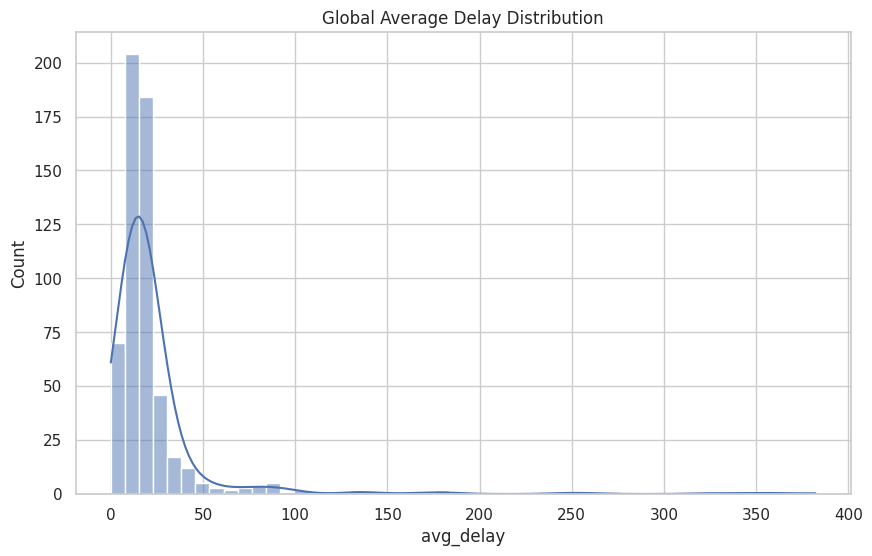

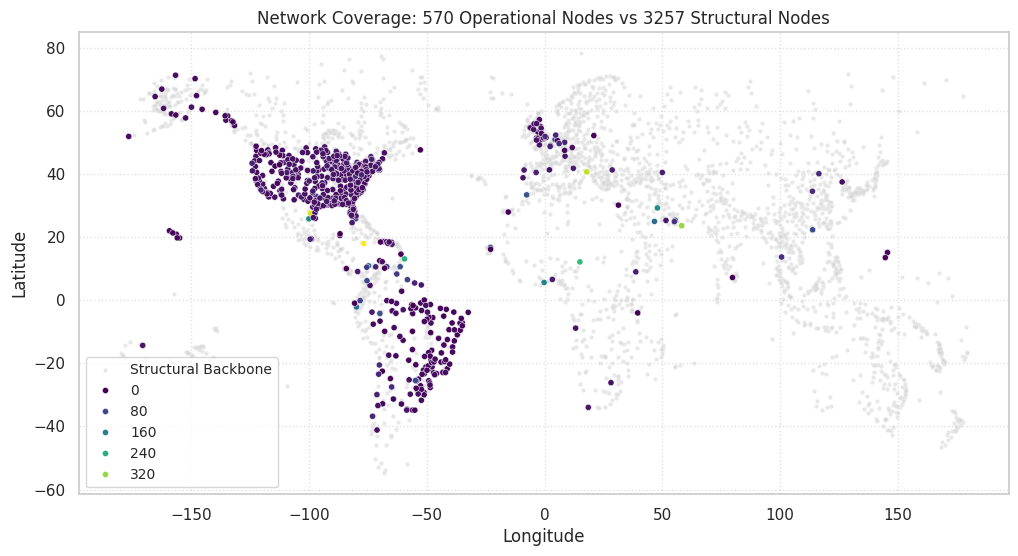

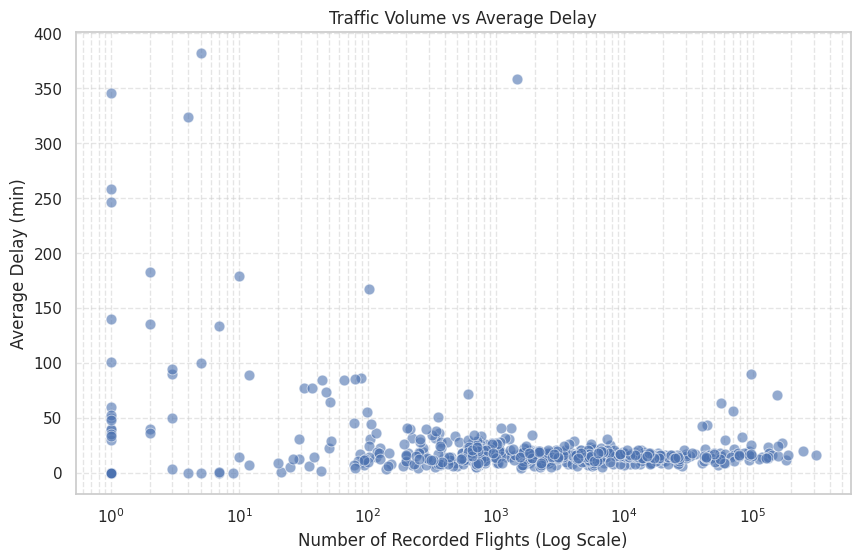

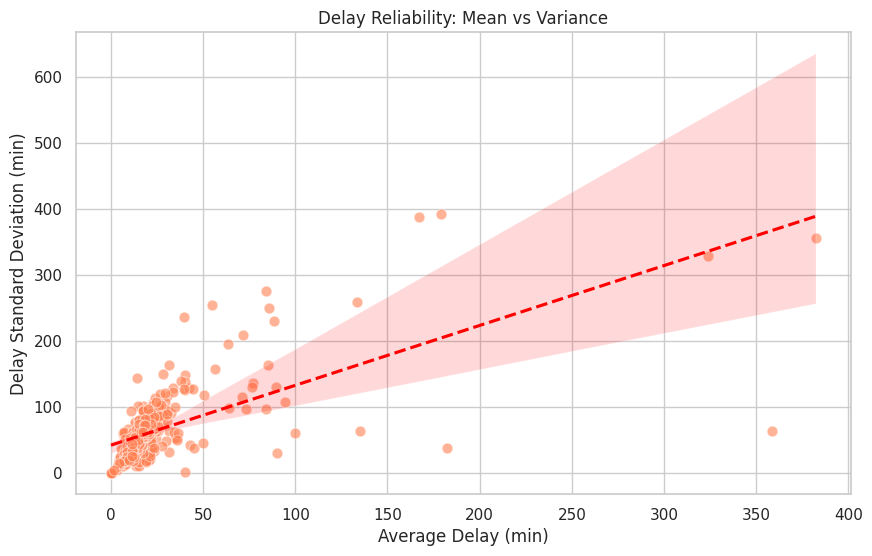

In [10]:
print("Generating Phase 1 Diagnostic Plots...")
# --- PLOT 1: DELAY DISTRIBUTION ---
plt.figure(figsize=(10, 6))
sns.histplot(df_master_nodes['avg_delay'].dropna(), bins=50, kde=True)
plt.title('Global Average Delay Distribution')
plt.show()
print()

# --- PLOT 2: GEOGRAPHIC COVERAGE (The "World Map") ---
plt.figure(figsize=(12, 6))
sns.scatterplot(
    x='Longitude', y='Latitude',
    data=df_master_nodes,
    color='lightgray', s=10, alpha=0.5, label='Structural Backbone'
)

df_with_data = df_master_nodes.dropna(subset=['avg_delay'])
sns.scatterplot(
    x='Longitude', y='Latitude',
    data=df_with_data,
    hue='avg_delay', palette='viridis', s=20, alpha=1.0
)

plt.title(f'Network Coverage: {len(df_with_data)} Operational Nodes vs {len(df_master_nodes)} Structural Nodes')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(loc='lower left', fontsize='small')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
print()

# --- PLOT 3: VOLUME VS DELAY (Efficiency Check) ---
if not df_with_data.empty and 'num_flights' in df_with_data.columns:
    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        x='num_flights', y='avg_delay',
        data=df_with_data,
        alpha=0.6, edgecolor='w', s=60
    )

    plt.xscale('log')
    plt.title('Traffic Volume vs Average Delay')
    plt.xlabel('Number of Recorded Flights (Log Scale)')
    plt.ylabel('Average Delay (min)')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()
    print()


# --- PLOT 4: RELIABILITY (Mean Delay vs Variance) ---
if not df_with_data.empty and 'delay_variance' in df_with_data.columns:
    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        x='avg_delay', y='delay_variance',
        data=df_with_data,
        alpha=0.6, color='coral', edgecolor='w', s=60
    )

    sns.regplot(
        x='avg_delay', y='delay_variance',
        data=df_with_data, scatter=False, color='red', line_kws={'linestyle': '--'}
    )

    plt.title('Delay Reliability: Mean vs Variance')
    plt.xlabel('Average Delay (min)')
    plt.ylabel('Delay Standard Deviation (min)')
    plt.grid(True)
    plt.show()

---
### **Phase 2**: Graph Construction and Fragility Analysis

In [11]:
print("Calculating Network Centrality Measures...")

gcc_nodes = max(nx.connected_components(G.to_undirected()), key=len)
G_gcc = G.subgraph(gcc_nodes).copy()

print("    - Calculating Degrees...")
in_degree_dict = dict(G.in_degree())
out_degree_dict = dict(G.out_degree())
total_degree_dict = dict(G.degree())

df_master_nodes["in_degree"] = df_master_nodes["IATA"].map(in_degree_dict)
df_master_nodes["out_degree"] = df_master_nodes["IATA"].map(out_degree_dict)
df_master_nodes["degree"] = df_master_nodes["IATA"].map(total_degree_dict)

print("    - Calculating PageRank...")
pagerank_dict = nx.pagerank(G, alpha=0.85)
df_master_nodes["pagerank"] = df_master_nodes["IATA"].map(pagerank_dict)

print("    - Calculating Betweenness...")
betweenness_dict = nx.betweenness_centrality(G, k=500, normalized=True, seed=42)
df_master_nodes["betweenness"] = df_master_nodes["IATA"].map(betweenness_dict)

print("    - Calculating Closeness (GCC)...")
closeness_gcc = nx.closeness_centrality(G_gcc)
df_master_nodes["closeness"] = df_master_nodes["IATA"].map(closeness_gcc)

print("    - Calculating Assortativity...")
assortativity = nx.degree_assortativity_coefficient(G)

print("    - Calculating ANND...")
knn_dict = nx.average_neighbor_degree(G)
df_master_nodes["knn"] = df_master_nodes["IATA"].map(knn_dict)

df_master_nodes["closeness"] = df_master_nodes["closeness"].fillna(0.0)
df_master_nodes["betweenness"] = df_master_nodes["betweenness"].fillna(0.0)
df_master_nodes["pagerank"] = df_master_nodes["pagerank"].fillna(0.0)

cols_to_analyze = [
    "in_degree", "out_degree", "degree",
    "pagerank", "betweenness", "closeness", "knn"
]

if "avg_delay" in df_master_nodes.columns:
    cols_to_analyze.append("avg_delay")

print("\nNetwork Centrality Summary:")
print(f"    - GCC Size:            {len(G_gcc)} nodes ({len(G_gcc)/len(G):.1%} of total)")
print(f"    - Assortativity:       {assortativity:.4f}")

stats = df_master_nodes[cols_to_analyze].describe().T

display_map = {
    "in_degree": "In-Degree", "out_degree": "Out-Degree", "degree": "Total Degree",
    "pagerank": "PageRank", "betweenness": "Betweenness", "closeness": "Closeness",
    "knn": "Avg Neighbor Degree", "avg_delay": "Average Delay"
}

for col in cols_to_analyze:
    if col in stats.index:
        row = stats.loc[col]
        name = display_map.get(col, col)
        print(f"    - {name:<20} min={row['min']:.4f}, max={row['max']:.4f}, mean={row['mean']:.4f}")

top_k = 5
print(f"\nTop {top_k} nodes by PageRank:")
print(df_master_nodes[["IATA", "pagerank"]].nlargest(top_k, "pagerank").to_string(index=False))

print(f"\nTop {top_k} nodes by Betweenness:")
print(df_master_nodes[["IATA", "betweenness"]].nlargest(top_k, "betweenness").to_string(index=False))

Calculating Network Centrality Measures...
    - Calculating Degrees...
    - Calculating PageRank...
    - Calculating Betweenness...
    - Calculating Closeness (GCC)...
    - Calculating Assortativity...
    - Calculating ANND...

Network Centrality Summary:
    - GCC Size:            3231 nodes (99.2% of total)
    - Assortativity:       -0.0443
    - In-Degree            min=0.0000, max=241.0000, mean=12.3866
    - Out-Degree           min=0.0000, max=244.0000, mean=12.3866
    - Total Degree         min=1.0000, max=485.0000, mean=24.7731
    - PageRank             min=0.0000, max=0.0045, mean=0.0003
    - Betweenness          min=0.0000, max=0.0596, mean=0.0009
    - Closeness            min=0.0000, max=0.4120, mean=0.2563
    - Avg Neighbor Degree  min=0.0000, max=239.0000, mean=60.1558
    - Average Delay        min=0.0000, max=382.2000, mean=23.0265

Top 5 nodes by PageRank:
IATA  pagerank
 DFW  0.004523
 IST  0.004471
 ORD  0.004412
 ATL  0.004358
 DEN  0.004265

Top 5 nodes 

#### Plotting Assortivity, Scale-Free Analysis, Correlation and Robustness

Analyzing Assortativity Trends...


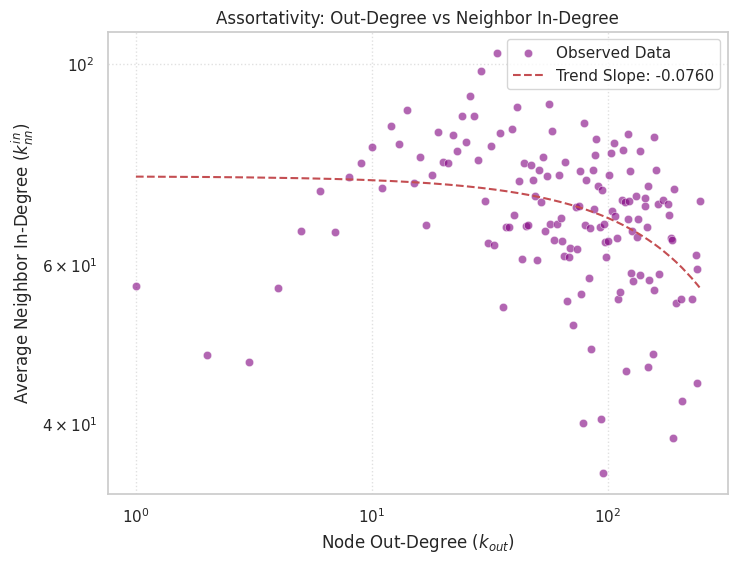



Verifying Scale-Free Property (PDF vs CCDF)...


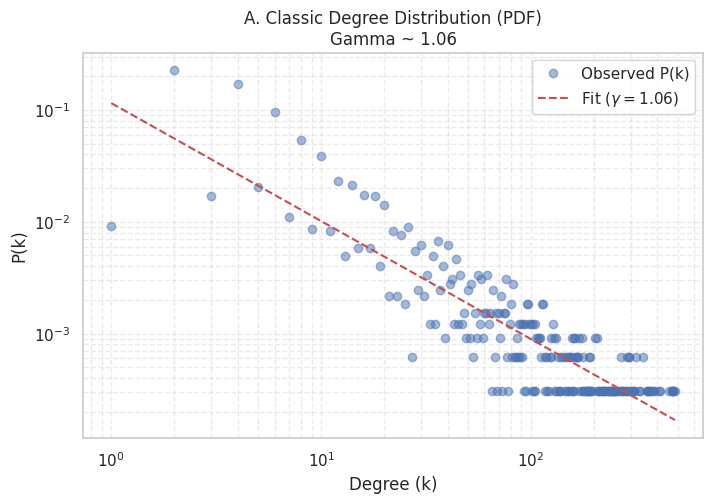

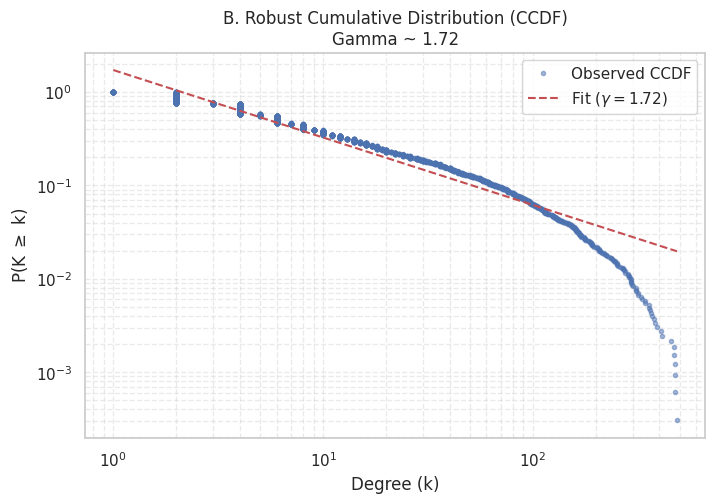

Gamma Estimates -> PDF: 1.06, CCDF: 1.72

Testing the 'Fragility Paradox' (Centrality vs Inefficiency)...
    - Pearson Correlation (Pandas):  0.0628
    - Spearman Correlation (Scipy): 0.0917 (p-value: 2.86e-02)
Hypothesis Test: INCONCLUSIVE: No strong correlation found.


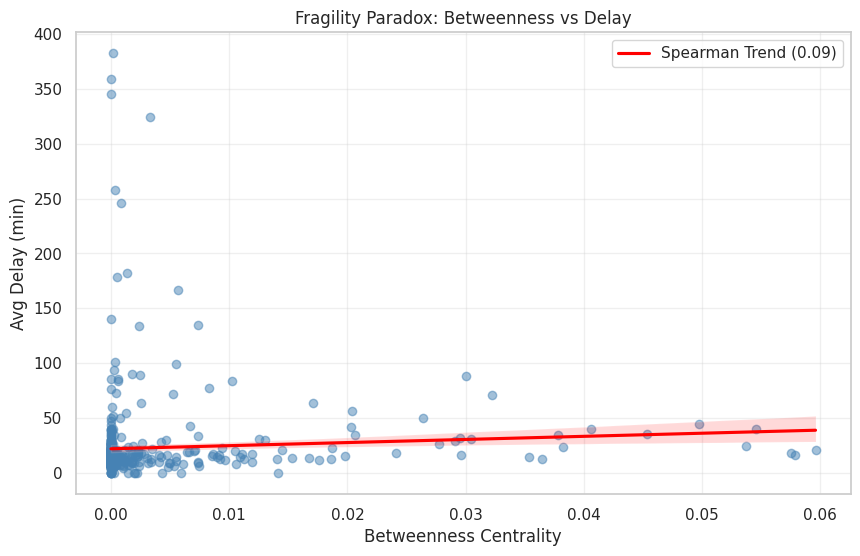



Running Network Disintegration Test (Local Simulation)...
    - Simulating Random, Structural, and Operational failure...


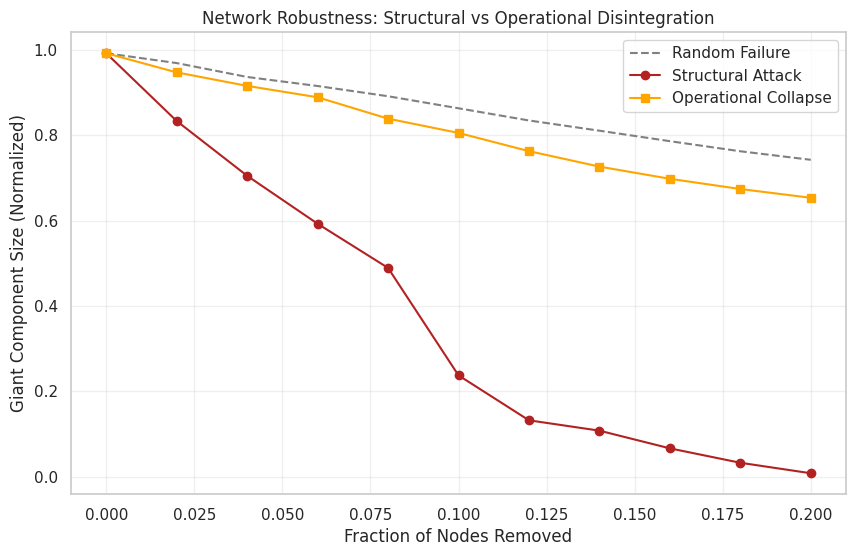

In [12]:
# ASSORTIVITY Plot: Out-Degree vs Average Neighbor In-Degree
print("Analyzing Assortativity Trends...")
df_annd = df_master_nodes.dropna(subset=["out_degree", "knn"])
df_annd = df_annd[df_annd["out_degree"] > 0]
k_vs_knn = df_annd.groupby("out_degree")["knn"].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='out_degree', y='knn', data=k_vs_knn, color='purple', alpha=0.6, label='Observed Data')
if len(k_vs_knn) > 1:
    z = np.polyfit(k_vs_knn['out_degree'], k_vs_knn['knn'], 1)
    p = np.poly1d(z)
    plt.plot(k_vs_knn['out_degree'], p(k_vs_knn['out_degree']), "r--", label=f'Trend Slope: {z[0]:.4f}')
plt.title("Assortativity: Out-Degree vs Neighbor In-Degree")
plt.xlabel("Node Out-Degree ($k_{out}$)")
plt.ylabel("Average Neighbor In-Degree ($k_{nn}^{in}$)")
plt.xscale('log'); plt.yscale('log')
plt.grid(True, linestyle=':', alpha=0.6); plt.legend()
plt.show()
print()

# SCALE-FREE Analysis: PDF vs CCDF
print("\nVerifying Scale-Free Property (PDF vs CCDF)...")
degrees = [d for n, d in G.degree() if d > 0]

# METHOD A: Classic PDF
degree_counts = pd.Series(degrees).value_counts().sort_index()
x_pdf = degree_counts.index.values
y_pdf = degree_counts.values / sum(degree_counts.values)
log_x_pdf = np.log(x_pdf); log_y_pdf = np.log(y_pdf)
coeffs_pdf = np.polyfit(log_x_pdf, log_y_pdf, 1)
gamma_pdf = -coeffs_pdf[0]

plt.figure(figsize=(8, 5))
plt.loglog(x_pdf, y_pdf, 'bo', alpha=0.5, label='Observed P(k)')
plt.loglog(x_pdf, np.exp(np.polyval(coeffs_pdf, log_x_pdf)), 'r--', label=f'Fit ($\gamma={gamma_pdf:.2f}$)')
plt.title(f"A. Classic Degree Distribution (PDF)\nGamma ~ {gamma_pdf:.2f}")
plt.xlabel("Degree (k)"); plt.ylabel("P(k)"); plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.4)
plt.show()
print()

# METHOD B: Robust CCDF
def get_ccdf_distribution(degrees):
    degrees_sorted = np.sort(np.array(degrees))
    ccdf = 1 - (np.arange(len(degrees_sorted)) / len(degrees_sorted))
    return degrees_sorted, ccdf

x_ccdf, y_ccdf = get_ccdf_distribution(degrees)
log_x_c = np.log(x_ccdf); log_y_c = np.log(y_ccdf)
coeffs_c = np.polyfit(log_x_c, log_y_c, 1)
gamma_ccdf = 1 - coeffs_c[0]

plt.figure(figsize=(8, 5))
plt.loglog(x_ccdf, y_ccdf, 'b.', alpha=0.5, label='Observed CCDF')
plt.loglog(x_ccdf, np.exp(np.polyval(coeffs_c, log_x_c)), 'r--', label=f'Fit ($\gamma={gamma_ccdf:.2f}$)')
plt.title(f"B. Robust Cumulative Distribution (CCDF)\nGamma ~ {gamma_ccdf:.2f}")
plt.xlabel("Degree (k)"); plt.ylabel("P(K $\geq$ k)"); plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.4)
plt.show()

print(f"Gamma Estimates -> PDF: {gamma_pdf:.2f}, CCDF: {gamma_ccdf:.2f}")

# CORRELATION Analysis: Betweenness vs Average Delay
print("\nTesting the 'Fragility Paradox' (Centrality vs Inefficiency)...")

if "avg_delay" in df_master_nodes.columns and "betweenness" in df_master_nodes.columns:
    df_valid = df_master_nodes.dropna(subset=["betweenness", "avg_delay"])

    if not df_valid.empty:
        # Pearson (Pandas)
        pearson_val = df_valid["betweenness"].corr(df_valid["avg_delay"], method="pearson")

        # Spearman (Scipy)
        s_corr, s_val = scipy_stats.spearmanr(df_valid["betweenness"], df_valid["avg_delay"])

        print(f"    - Pearson Correlation (Pandas):  {pearson_val:.4f}")
        print(f"    - Spearman Correlation (Scipy): {s_corr:.4f} (p-value: {s_val:.2e})")

        if s_corr > 0.1:
            conclusion = "CONFIRMED: Central Hubs tend to have higher delays."
        elif s_corr < -0.1:
            conclusion = "REJECTED: Central Hubs are actually more efficient."
        else:
            conclusion = "INCONCLUSIVE: No strong correlation found."
        print(f"Hypothesis Test: {conclusion}")

        # Plot
        plt.figure(figsize=(10, 6))
        sns.regplot(
            x='betweenness', y='avg_delay',
            data=df_valid,
            scatter_kws={'alpha': 0.5, 'color': 'steelblue'},
            line_kws={'color': 'red', 'label': f'Spearman Trend ({s_corr:.2f})'}
        )
        plt.title('Fragility Paradox: Betweenness vs Delay')
        plt.xlabel('Betweenness Centrality')
        plt.ylabel('Avg Delay (min)')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()
        print()
    else:
        print("Not enough data for correlation analysis.")
else:
    print("Warning: 'avg_delay' or 'betweenness' column missing.")

# ROBUSTNESS test: Random vs Targeted Attacks
print("\nRunning Network Disintegration Test (Local Simulation)...")
def get_giant_component_fraction(g_curr, original_n):
    if len(g_curr) == 0: return 0
    gc = max(nx.weakly_connected_components(g_curr), key=len)
    return len(gc) / original_n

fractions = np.linspace(0, 0.20, 11)
results = {"Random": [], "Structural": [], "Operational": []}
original_nodes = G.number_of_nodes()

# Using Spark to sort nodes by centrality and delay for targeted attacks
df_prep = df_master_nodes.fillna({'pagerank': 0.0, 'avg_delay': 0.0})

random_attack = list(G.nodes()); random.shuffle(random_attack)
structural_attack = df_prep.sort_values("pagerank", ascending=False)["IATA"].tolist()
operational_attack = df_prep.sort_values("avg_delay", ascending=False)["IATA"].tolist()

print("    - Simulating Random, Structural, and Operational failure...")
for f in fractions:
    n_rem = int(original_nodes * f)

    def simulate_attack(attack_list):
        G_tmp = G.copy()
        # Remove first n_rem nodes
        targets = [n for n in attack_list[:n_rem] if n in G_tmp]
        G_tmp.remove_nodes_from(targets)
        return get_giant_component_fraction(G_tmp, original_nodes)

    results["Random"].append(simulate_attack(random_attack))
    results["Structural"].append(simulate_attack(structural_attack))
    results["Operational"].append(simulate_attack(operational_attack))

plt.figure(figsize=(10, 6))
plt.plot(fractions, results["Random"], '--', color='gray', label="Random Failure")
plt.plot(fractions, results["Structural"], 'o-', color='firebrick', label="Structural Attack")
plt.plot(fractions, results["Operational"], 's-', color='orange', label="Operational Collapse")
plt.title("Network Robustness: Structural vs Operational Disintegration")
plt.xlabel("Fraction of Nodes Removed"); plt.ylabel("Giant Component Size (Normalized)")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

---
### **Phase 3**: Clustering

#### K-Means, Silhouette/Davies-Bouldin/Calinski-Harabasz Analysis

Preparing Feature Matrix for Clustering...
    - Data points available for clustering: 548

Running K-Means Grid Search...
    - Testing k from 2 to 6...
      k=2 | Sil: 0.704 | DB: 0.915 | CH: 382.9
      k=3 | Sil: 0.709 | DB: 0.734 | CH: 416.5
      k=4 | Sil: 0.587 | DB: 0.803 | CH: 412.2
      k=5 | Sil: 0.576 | DB: 0.814 | CH: 405.2
      k=6 | Sil: 0.354 | DB: 0.840 | CH: 403.1


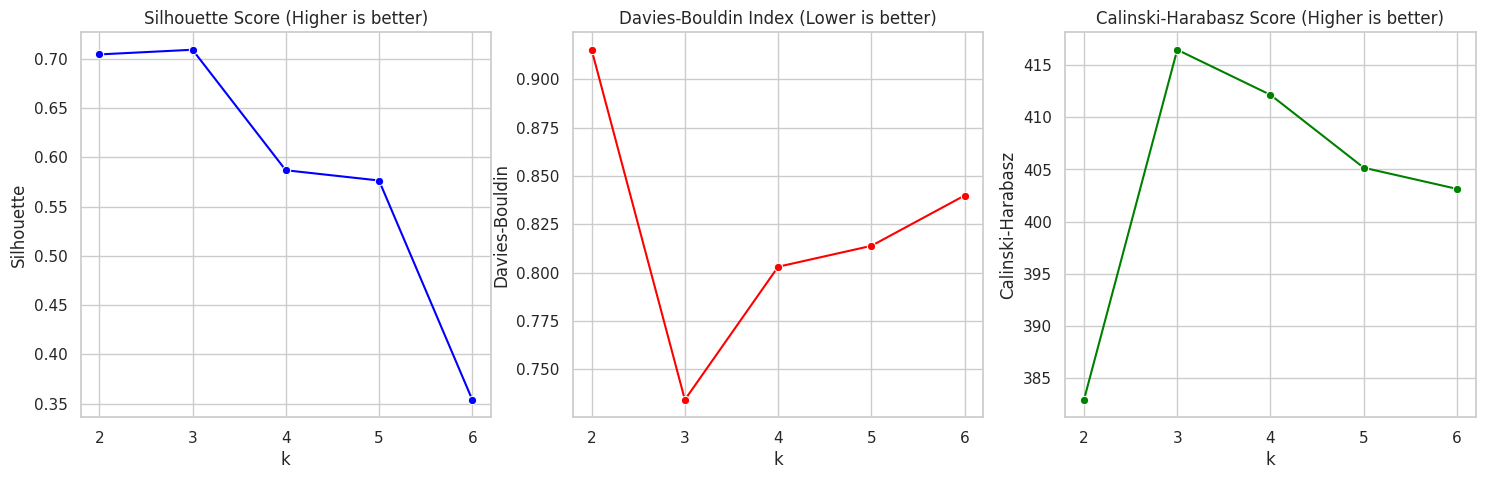

In [13]:
print("Preparing Feature Matrix for Clustering...")

# Selection of features for clustering (only those with good coverage and relevance)
features_cols = ['pagerank', 'betweenness', 'avg_delay', 'delay_variance', 'degree']

# Drop missing values (ML don't accept Null)
df_model_pd = df_master_nodes.dropna(subset=features_cols).copy()
print(f"    - Data points available for clustering: {len(df_model_pd)}")

scaler = SklearnScaler()
X = df_model_pd[features_cols].values
X_scaled = scaler.fit_transform(X)

# K-MEANS GRID SEARCH
print("\nRunning K-Means Grid Search...")
k_range = range(2, 7)
results = []

print(f"    - Testing k from {min(k_range)} to {max(k_range)}...")

for k in k_range:
    # Train
    kmeans = SklearnKMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    # Metrics
    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)

    results.append({"k": k, "Silhouette": sil, "Davies-Bouldin": db, "Calinski-Harabasz": ch})
    print(f"      k={k} | Sil: {sil:.3f} | DB: {db:.3f} | CH: {ch:.1f}")

# Plot
df_metrics = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.lineplot(x='k', y='Silhouette', data=df_metrics, marker='o', ax=axes[0], color='blue')
axes[0].set_title('Silhouette Score (Higher is better)')

sns.lineplot(x='k', y='Davies-Bouldin', data=df_metrics, marker='o', ax=axes[1], color='red')
axes[1].set_title('Davies-Bouldin Index (Lower is better)')

sns.lineplot(x='k', y='Calinski-Harabasz', data=df_metrics, marker='o', ax=axes[2], color='green')
axes[2].set_title('Calinski-Harabasz Score (Higher is better)')

plt.grid(True)
plt.show()
print()

#### Plotting clusters

Applying Final K-Means Model with k=3 (Manual Selection)...

Exploratory Analysis (Hierarchical & DBSCAN)...
    - Hierarchical Clustering (Top 100 Dendrogram)...


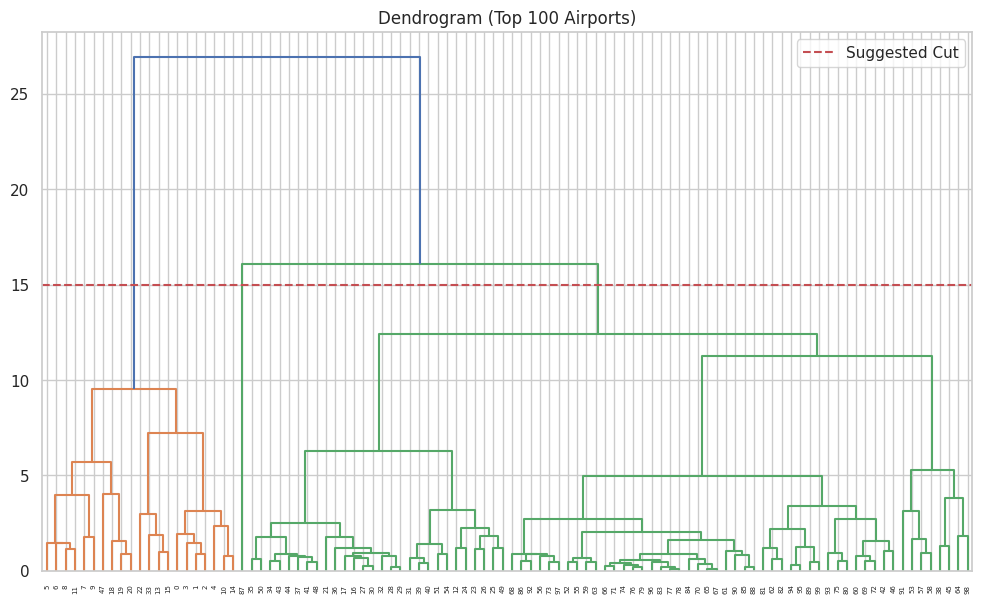


    - DBSCAN for Outlier Detection...


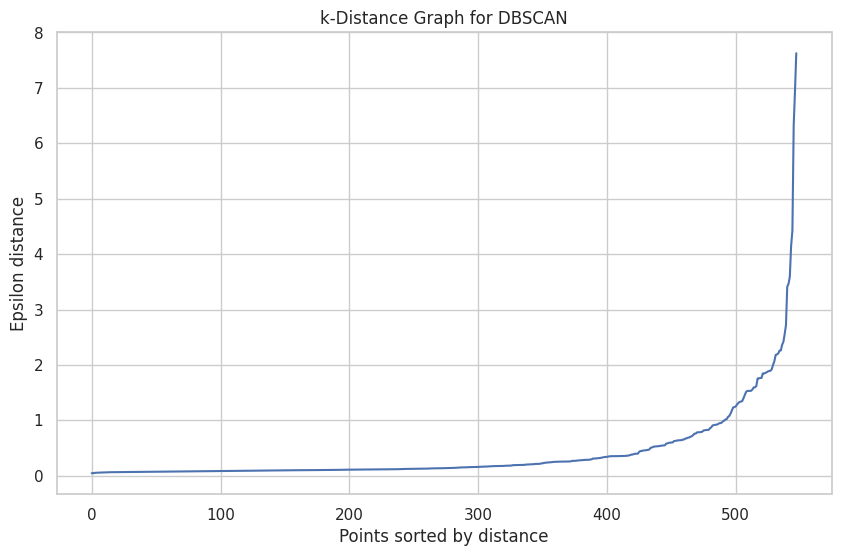


    -> DBSCAN found 44 outliers (Noise points labeled as -1)

PCA Projection & Profiling...


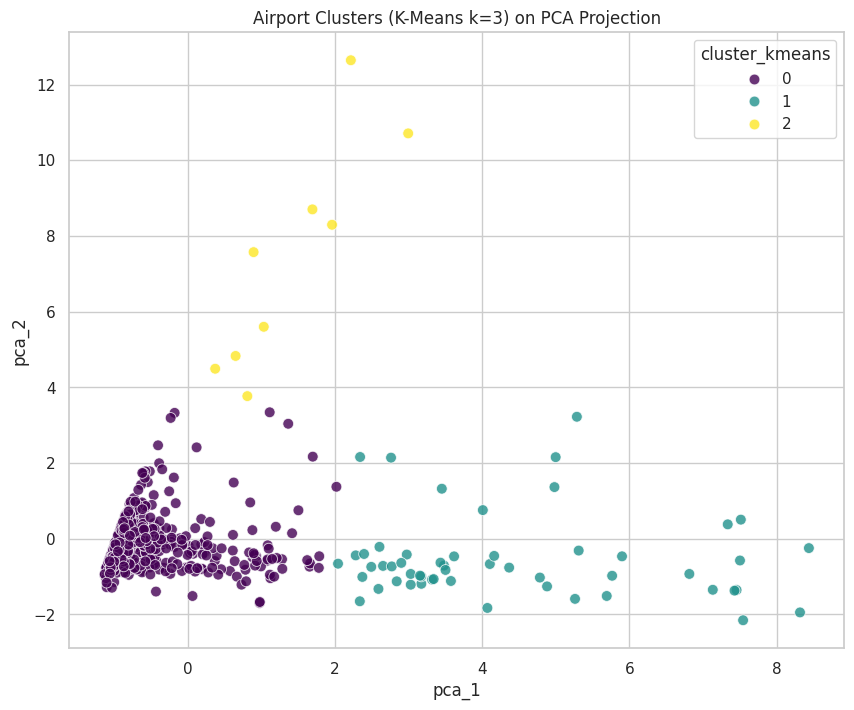

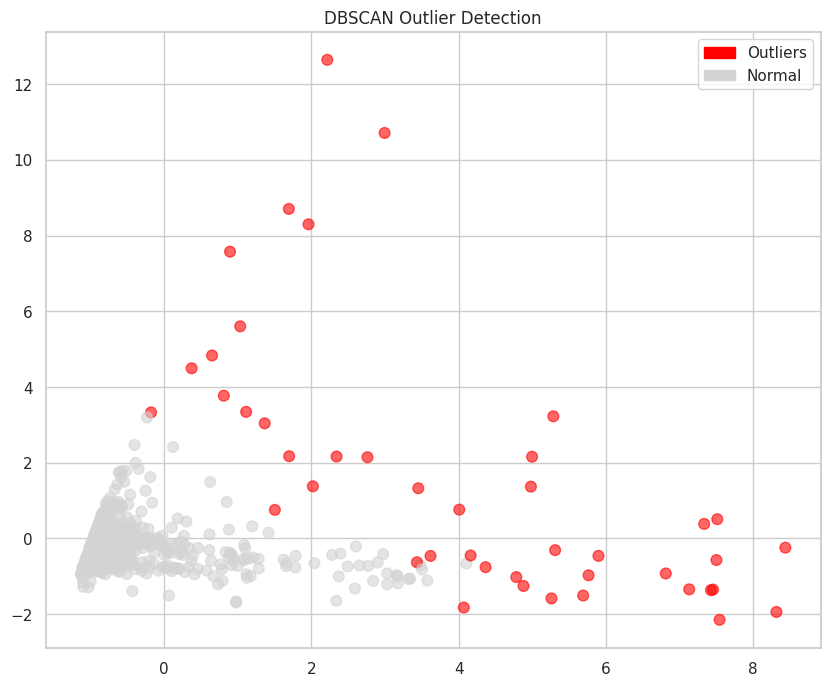


    - Generating Profiling Boxplots...


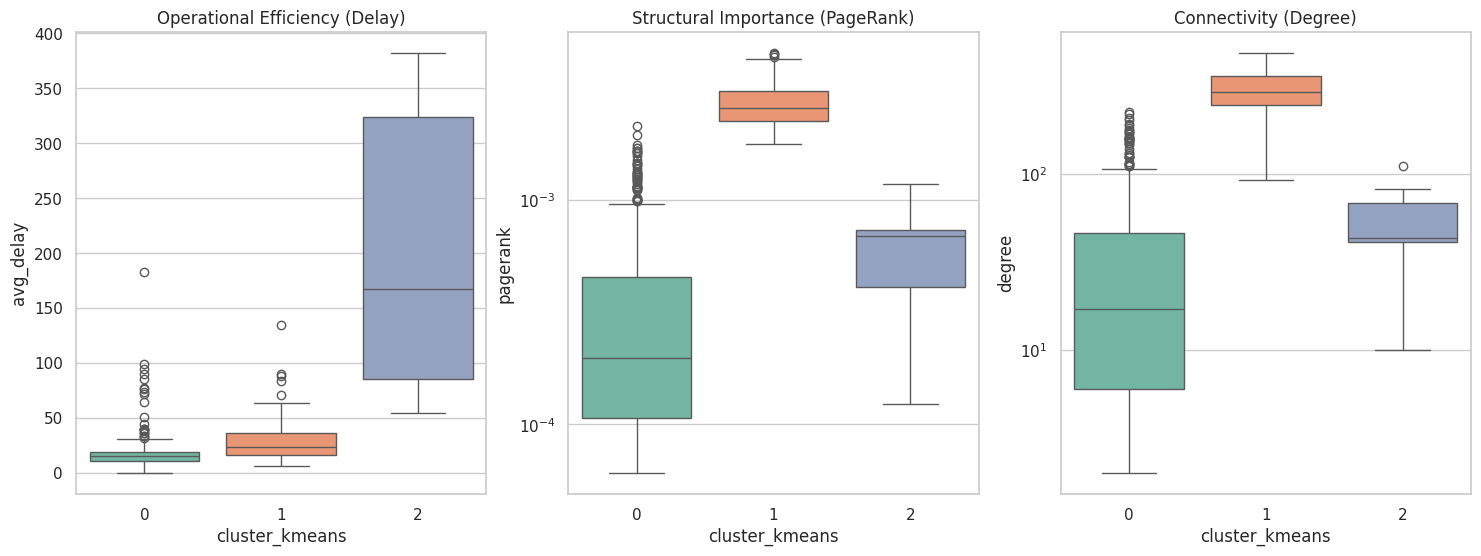

In [14]:
# SELECTION OF BEST K (Manual based on metrics)
best_k = 3
print(f"Applying Final K-Means Model with k={best_k} (Manual Selection)...")

# We need to re-train the model with k=3 because the previous loop ended at k=6
kmeans_final = SklearnKMeans(n_clusters=best_k, random_state=42, n_init=10)
df_model_pd["cluster_kmeans"] = kmeans_final.fit_predict(X_scaled)

# HIERARCHICAL & DBSCAN clusterinf
print("\nExploratory Analysis (Hierarchical & DBSCAN)...")
print("    - Hierarchical Clustering (Top 100 Dendrogram)...")

top_100_indices = df_model_pd.sort_values("pagerank", ascending=False).head(100).index
X_sample = df_model_pd.loc[top_100_indices, features_cols].values
X_sample_scaled = scaler.transform(X_sample)

plt.figure(figsize=(12, 7))
plt.title("Dendrogram (Top 100 Airports)")
dend = shc.dendrogram(shc.linkage(X_sample_scaled, method='ward'))
plt.axhline(y=15, color='r', linestyle='--', label="Suggested Cut")
plt.legend()
plt.show()
print()

# DBSCAN for Outlier Detection
print("    - DBSCAN for Outlier Detection...")
# Parameters: eps and min_samples need to be tuned. We use k-distance graph.
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, min_samples-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title("k-Distance Graph for DBSCAN")
plt.xlabel("Points sorted by distance"); plt.ylabel("Epsilon distance")
plt.grid(True)
plt.show()
print()

# Apply DBSCAN (eps=1.0 empirical, adjust if the graph suggests otherwise)
eps_value = 1.0
dbscan = SklearnDBSCAN(eps=eps_value, min_samples=min_samples)
df_model_pd["cluster_dbscan"] = dbscan.fit_predict(X_scaled)

n_outliers = list(df_model_pd["cluster_dbscan"]).count(-1)
print(f"    -> DBSCAN found {n_outliers} outliers (Noise points labeled as -1)")

# VISUALIZATION (PCA)
print("\nPCA Projection & Profiling...")

pca = PCA(n_components=2)
principalComponents = pca.fit_transform(X_scaled)
df_model_pd['pca_1'] = principalComponents[:, 0]
df_model_pd['pca_2'] = principalComponents[:, 1]

# Plot K-Means Clusters (Calculated by Spark)
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="pca_1", y="pca_2", hue="cluster_kmeans",
    data=df_model_pd, palette="viridis", s=60, alpha=0.8
)
plt.title(f"Airport Clusters (K-Means k={best_k}) on PCA Projection")
plt.show()
print()

# Plot DBSCAN Outliers
plt.figure(figsize=(10, 8))
colors = np.where(df_model_pd["cluster_dbscan"] == -1, 'red', 'lightgray')
plt.scatter(df_model_pd["pca_1"], df_model_pd["pca_2"], c=colors, s=60, alpha=0.6)
red_patch = mpatches.Patch(color='red', label='Outliers')
gray_patch = mpatches.Patch(color='lightgray', label='Normal')
plt.legend(handles=[red_patch, gray_patch])
plt.title("DBSCAN Outlier Detection")
plt.show()
print()

# PROFILING (Boxplots)
print("    - Generating Profiling Boxplots...")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(x='cluster_kmeans', y='avg_delay', data=df_model_pd, ax=axes[0], palette="Set2")
axes[0].set_title("Operational Efficiency (Delay)")

sns.boxplot(x='cluster_kmeans', y='pagerank', data=df_model_pd, ax=axes[1], palette="Set2")
axes[1].set_yscale('log')
axes[1].set_title("Structural Importance (PageRank)")

sns.boxplot(x='cluster_kmeans', y='degree', data=df_model_pd, ax=axes[2], palette="Set2")
axes[2].set_yscale('log')
axes[2].set_title("Connectivity (Degree)")

plt.show()

---
### **Phase 4**: Recommendation System

#### S-Curve Analysis, LSH, Efficient evaluation

Analyzing LSH parameters (S-Curve)...
    - Configuration: Perm=128, Bands=32, Rows=4
    - Theoretical Threshold: 0.42


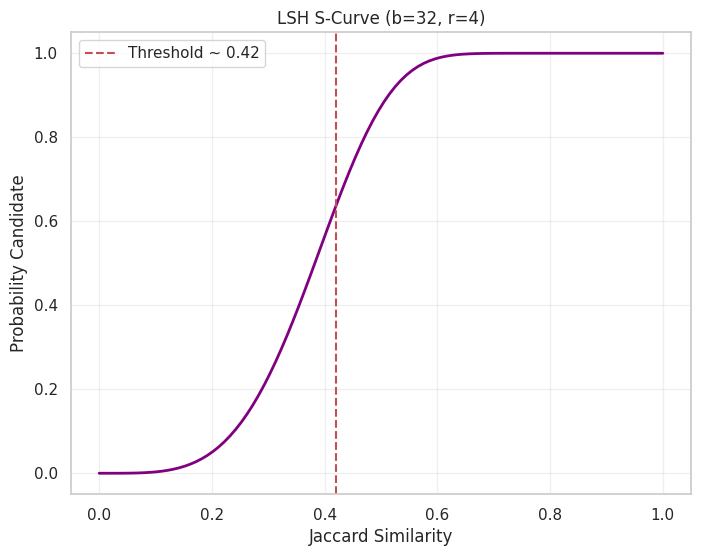

Setting 'IATA' as DataFrame Index...

Generating MinHash Signatures (Local)...
    - Indexed 547 airports in 0.88 seconds.

Testing Computational Efficiency (Brute Force vs LSH)...
    - Brute Force Avg Time: 0.0058 s
    - LSH Avg Time:         0.0001 s
    -> Speedup Factor: 95.1x Faster


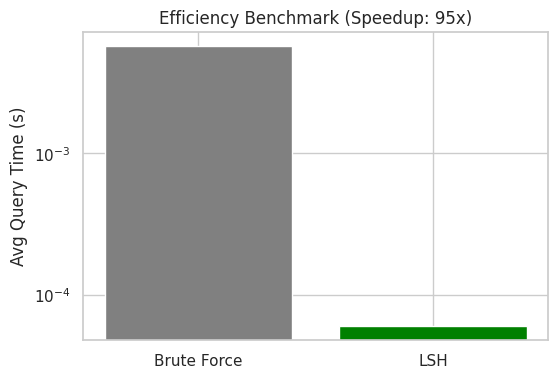


Running 'Smart Switch' Engine...
    - Target Cluster: #2 (Avg Delay: 196.5 min)
    - Finding alternatives for 9 bottlenecks...

Analyzing Recommendations Score...

TOP 20 SMART RECOMMENDATIONS (Spark Sorted)
Bottleneck_Airport Recommended_Twin  Similarity  Current_Delay  Potential_Gain Capacity_Match
               LRD              YUM    0.333333     358.324881      343.921259        10 vs 6
               LRD              MLU    0.333333     358.324881      341.829638        10 vs 6
               LRD              GRK    0.333333     358.324881      341.031366        10 vs 6
               LRD              FLG    0.333333     358.324881      340.613238        10 vs 6
               LRD              GRI    0.333333     358.324881      332.328096        10 vs 6
               LRD              AMA    0.300000     358.324881      344.850168       10 vs 15
               LRD              MAF    0.300000     358.324881      344.203599       10 vs 17
               LRD              AEX  

In [15]:
# THEORETICAL TUNING (THE S-CURVE)
print("Analyzing LSH parameters (S-Curve)...")
num_perm = 128
b = 32; r = 4
threshold_theoretical = (1/b)**(1/r)

print(f"    - Configuration: Perm={num_perm}, Bands={b}, Rows={r}")
print(f"    - Theoretical Threshold: {threshold_theoretical:.2f}")

# plot
s_values = np.linspace(0, 1, 100)
prob_candidate = 1 - (1 - s_values**r)**b

plt.figure(figsize=(8, 6))
plt.plot(s_values, prob_candidate, color='purple', linewidth=2)
plt.axvline(x=threshold_theoretical, color='r', linestyle='--', label=f'Threshold ~ {threshold_theoretical:.2f}')
plt.title(f"LSH S-Curve (b={b}, r={r})")
plt.xlabel("Jaccard Similarity")
plt.ylabel("Probability Candidate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Important: sets IATA as row key
if "IATA" in df_model_pd.columns:
    print("Setting 'IATA' as DataFrame Index...")
    df_model_pd = df_model_pd.set_index("IATA")

# SIGNATURE GENERATION & INDEXING
print("\nGenerating MinHash Signatures (Local)...")
# LSH is extremely efficient in-memory

lsh = MinHashLSH(threshold=threshold_theoretical, num_perm=num_perm)
minhashes = {}
valid_airports = []

start_time = time.time()
for n in G.nodes():
    n_str = str(n)
    if n_str in df_model_pd.index:
        destinations = list(G.successors(n))
        if destinations:
            m = MinHash(num_perm=num_perm)
            for d in destinations:
                m.update(str(d).encode('utf8'))
            minhashes[n_str] = m
            lsh.insert(n_str, m)
            valid_airports.append(n_str)

print(f"    - Indexed {len(valid_airports)} airports in {time.time() - start_time:.2f} seconds.")

# EFFICIENCY BENCHMARK
print("\nTesting Computational Efficiency (Brute Force vs LSH)...")
sample_size = 50
sample_nodes = valid_airports[:min(len(valid_airports), sample_size)]

# Brute Force
start_bf = time.time()
for n1 in sample_nodes:
    set1 = set(G.successors(n1)) if n1 in G else set()
    for n2 in valid_airports:
        if n1 == n2: continue
        set2 = set(G.successors(n2)) if n2 in G else set()
        if not set1 or not set2: continue
        _ = len(set1.intersection(set2)) / len(set1.union(set2))
avg_bf_time = (time.time() - start_bf) / sample_size

# LSH Query
start_lsh = time.time()
for n1 in sample_nodes:
    if n1 in minhashes:
        _ = lsh.query(minhashes[n1])
avg_lsh_time = (time.time() - start_lsh) / sample_size

print(f"    - Brute Force Avg Time: {avg_bf_time:.4f} s")
print(f"    - LSH Avg Time:         {avg_lsh_time:.4f} s")
speedup = avg_bf_time / avg_lsh_time if avg_lsh_time > 0 else 0
print(f"    -> Speedup Factor: {speedup:.1f}x Faster")

plt.figure(figsize=(6, 4))
plt.bar(['Brute Force', 'LSH'], [avg_bf_time, avg_lsh_time], color=['gray', 'green'])
plt.ylabel("Avg Query Time (s)"); plt.yscale('log')
plt.title(f"Efficiency Benchmark (Speedup: {speedup:.0f}x)")
plt.show()

# Recommendation System
print("\nRunning 'Smart Switch' Engine...")

if "cluster_kmeans" in df_model_pd.columns:
    # Identify bottleneck cluster (highest average delay)
    cluster_delays = df_model_pd.groupby("cluster_kmeans")["avg_delay"].mean()
    bottleneck_cluster = cluster_delays.idxmax()
    bottleneck_airports = df_model_pd[df_model_pd["cluster_kmeans"] == bottleneck_cluster].index.tolist()

    print(f"    - Target Cluster: #{bottleneck_cluster} (Avg Delay: {cluster_delays[bottleneck_cluster]:.1f} min)")
    print(f"    - Finding alternatives for {len(bottleneck_airports)} bottlenecks...")

    recommendations = []

    # Recommendation Loop
    for b_node in bottleneck_airports:
        if b_node not in minhashes: continue

        # LSH Query
        candidates = lsh.query(minhashes[b_node])
        b_data = df_model_pd.loc[b_node]

        for c_node in candidates:
            if c_node == b_node or c_node not in df_model_pd.index: continue
            c_data = df_model_pd.loc[c_node]

            delay_diff = b_data["avg_delay"] - c_data["avg_delay"]
            if delay_diff <= 5: continue # Minimum gain of 5 minutes
            if c_data["degree"] < (0.5 * b_data["degree"]): continue # Minimum capacity 50%

            # Exact Jaccard calculation for validation
            set1 = set(G.successors(b_node)); set2 = set(G.successors(c_node))
            if not set1.union(set2): continue
            exact_jaccard = len(set1.intersection(set2)) / len(set1.union(set2))

            recommendations.append({
                "Bottleneck_Airport": b_node,
                "Recommended_Twin": c_node,
                "Similarity": float(exact_jaccard),
                "Current_Delay": float(b_data["avg_delay"]),
                "Expected_Delay": float(c_data["avg_delay"]),
                "Potential_Gain": float(delay_diff),
                "Capacity_Match": f"{int(b_data['degree'])} vs {int(c_data['degree'])}"
            })

    # FINAL ANALYTICS
    if recommendations:
        print("\nAnalyzing Recommendations Score...")
        df_recs = pd.DataFrame(recommendations)

        # Calculate Smart Score
        df_recs["Score"] = df_recs["Potential_Gain"] * df_recs["Similarity"]
        df_recs_sorted = df_recs.sort_values("Score", ascending=False)

        print("\n" + "="*30)
        print("TOP 20 SMART RECOMMENDATIONS (Spark Sorted)")
        print("="*30)

        # Display nicely
        display_cols = ["Bottleneck_Airport", "Recommended_Twin", "Similarity",
                        "Current_Delay", "Potential_Gain", "Capacity_Match"]
        print(df_recs_sorted[display_cols].head(20).to_string(index=False))

        # Stats
        valid_recs = len(df_recs[df_recs["Similarity"] > 0.3])
        print(f"\n    -> Total Recommendations Found: {len(df_recs)}")
        print(f"    -> Quality Check: {valid_recs}/{len(df_recs)} recommendations have High Similarity (>0.3)")
        print(f"    -> Average Potential Gain: {df_recs['Potential_Gain'].mean():.1f} min")
        print(f"    -> Max Potential Gain:     {df_recs['Potential_Gain'].max():.1f} min")
    else:
        print("\n   [!] No valid recommendations found matching all business constraints.")

else:
    print("[ERROR] 'cluster_kmeans' column missing.")

print("\nPROJECT COMPLETED SUCCESSFULLY")